In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics tensorflow -q
import os
import cv2
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Automatically detect correct base path
root_path = "/content/drive/MyDrive/datasets/ua_detrac"

if os.path.exists(os.path.join(root_path, "DETRAC-Images", "DETRAC-Images")):
    base_path = os.path.join(root_path, "DETRAC-Images", "DETRAC-Images")
else:
    base_path = os.path.join(root_path, "DETRAC-Images")

print("Using base path:", base_path)
print("Sample folders:", os.listdir(base_path)[:3])

Using base path: /content/drive/MyDrive/datasets/ua_detrac/DETRAC-Images/DETRAC-Images
Sample folders: ['MVI_20011', 'MVI_20012', 'MVI_20032']


In [ ]:
model = YOLO("yolov8n.pt")
vehicle_classes = [2, 3, 5, 7]  # car, motorcycle, bus, truck

In [ ]:
all_counts = []
MAX_FRAMES_PER_FOLDER = 300   # limit for speed

for folder in sorted(os.listdir(base_path))[:40]:
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        images = sorted(os.listdir(folder_path))[:MAX_FRAMES_PER_FOLDER]

        for img_name in images:
            img_path = os.path.join(folder_path, img_name)

            frame = cv2.imread(img_path)
            results = model(frame, verbose=False)

            count = sum(int(box.cls) in vehicle_classes for box in results[0].boxes)

            all_counts.append(count)

print("Total Frames Processed:", len(all_counts))

Processing: MVI_20011
Processing: MVI_20012
Processing: MVI_20032
Processing: MVI_20033
Processing: MVI_20034
Processing: MVI_20035
Processing: MVI_20051
Processing: MVI_20052
Processing: MVI_20061
Processing: MVI_20062
Processing: MVI_20063
Processing: MVI_20064
Processing: MVI_20065
Processing: MVI_39031
Processing: MVI_39051
Processing: MVI_39211
Processing: MVI_39271
Processing: MVI_39311
Processing: MVI_39361
Processing: MVI_39371
Processing: MVI_39401
Processing: MVI_39501
Processing: MVI_39511
Processing: MVI_39761
Processing: MVI_39771
Processing: MVI_39781
Processing: MVI_39801
Processing: MVI_39811
Processing: MVI_39821
Processing: MVI_39851
Processing: MVI_39861
Processing: MVI_39931
Processing: MVI_40131
Processing: MVI_40141
Processing: MVI_40152
Processing: MVI_40161
Processing: MVI_40162
Processing: MVI_40171
Processing: MVI_40172
Processing: MVI_40181
Total Frames Processed: 12000


In [ ]:
FRAMES_PER_MIN = 60

minute_counts = []

for i in range(0, len(all_counts), FRAMES_PER_MIN):
    chunk = all_counts[i:i+FRAMES_PER_MIN]
    if len(chunk) > 0:
        minute_counts.append(np.mean(chunk))

print("Total Minutes Generated:", len(minute_counts))

Total Minutes Generated: 200


In [ ]:
start_time = datetime.datetime(2024, 1, 1, 7, 30)

timestamps = [
    start_time + datetime.timedelta(minutes=i)
    for i in range(len(minute_counts))
]

df = pd.DataFrame({
    "timestamp": timestamps,
    "vehicle_count": minute_counts
})

df.head()


,timestamp,vehicle_count
0,2024-01-01 07:30:00,15.950000
1,2024-01-01 07:31:00,19.450000
2,2024-01-01 07:32:00,20.033333
3,2024-01-01 07:33:00,17.450000
4,2024-01-01 07:34:00,16.933333


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[["vehicle_count"]])

def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(scaled_data, time_step)

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(time_step,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1490
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0515 
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0473 
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0435 
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0407 
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0406 
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0393 
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0388 
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0378 
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0378 
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0372 
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0356 
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0349 
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0342 
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0332 
Epoch

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[["vehicle_count"]])

def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(scaled_data, time_step)

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(time_step,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1975
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0543 
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0573 
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0459 
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0463 
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0433 
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0427 
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0418 
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0409 
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0400 
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0392 
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0385 
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0378 
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0370 
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0363 
Epoch 16/20
10/1

In [ ]:
pred = lstm_model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_actual, pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred))

epsilon = 1e-10
mape = np.mean(np.abs((y_test_actual - pred) / (y_test_actual + epsilon))) * 100
accuracy = 100 - mape

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("Prediction Accuracy:", round(accuracy,2), "%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
MAE: 3.04
RMSE: 3.62
Prediction Accuracy: 62.93 %


In [ ]:
last_sequence = scaled_data[-time_step:]
current_input = last_sequence.reshape(1, time_step, 1)

future_predictions = []

for i in range(15):
    next_pred = lstm_model.predict(current_input, verbose=0)
    future_predictions.append(next_pred[0][0])
    current_input = np.concatenate(
        (current_input[:,1:,:], next_pred.reshape(1,1,1)),
        axis=1
    )
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

future_predictions = np.round(future_predictions).astype(int)


In [ ]:
def full_demo(image_path):

    global minute_counts, scaler, lstm_model, accuracy

    # ---- Step 1: Detect Vehicles ----
    results = model(image_path)
    count = sum(int(box.cls) in vehicle_classes for box in results[0].boxes)
    annotated = results[0].plot()

    # ---- Step 2: Create Temporary Updated Sequence ----
    temp_minute_counts = minute_counts.copy()

    # Replace last minute value with current count
    if len(temp_minute_counts) > 0:
        temp_minute_counts[-1] = count

    updated_df = pd.DataFrame({"vehicle_count": temp_minute_counts})
    scaled_data = scaler.transform(updated_df[["vehicle_count"]])

    time_step = 10

    if len(scaled_data) > time_step:

        last_sequence = scaled_data[-time_step:]
        current_input = last_sequence.reshape(1, time_step, 1)

        future_predictions = []

        for i in range(15):
            next_pred = lstm_model.predict(current_input, verbose=0)
            future_predictions.append(next_pred[0][0])

            current_input = np.concatenate(
                (current_input[:,1:,:], next_pred.reshape(1,1,1)),
                axis=1
            )

        future_predictions = scaler.inverse_transform(
            np.array(future_predictions).reshape(-1,1)
        )

        future_predictions = np.round(future_predictions).astype(int)

    else:
        future_predictions = ["Not enough data"]

    # ---- Step 3: Density ----
    max_capacity = max(minute_counts)
    density_percent = (count / max_capacity) * 100

    if density_percent < 40:
        density_label = "Low"
    elif density_percent < 75:
        density_label = "Medium"
    else:
        density_label = "High"

    # ---- Step 4: Display ----
    cv2.putText(annotated, f"Count: {count}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.putText(annotated,
                f"Density: {density_label} ({density_percent:.1f}%)",
                (20,80),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Real-Time Traffic Analysis")
    plt.show()

    print("Vehicle Count:", count)
    print("Traffic Density:", density_label)
    print("Prediction Accuracy:", round(accuracy,2), "%")

    print("\nNext 15 Minute Prediction:")
    print(np.array(future_predictions).flatten())

In [ ]:
print(os.listdir(base_path))

['MVI_20011', 'MVI_20012', 'MVI_20032', 'MVI_20033', 'MVI_20034', 'MVI_20035', 'MVI_20051', 'MVI_20052', 'MVI_20061', 'MVI_20062', 'MVI_20063', 'MVI_20064', 'MVI_20065', 'MVI_39031', 'MVI_39051', 'MVI_39211', 'MVI_39271', 'MVI_39311', 'MVI_39361', 'MVI_39371', 'MVI_39401', 'MVI_39501', 'MVI_39511', 'MVI_39761', 'MVI_39771', 'MVI_39781', 'MVI_39801', 'MVI_39811', 'MVI_39821', 'MVI_39851', 'MVI_39861', 'MVI_39931', 'MVI_40131', 'MVI_40141', 'MVI_40152', 'MVI_40161', 'MVI_40162', 'MVI_40171', 'MVI_40172', 'MVI_40181', 'MVI_40191', 'MVI_40192']


In [ ]:
folder_name = "MVI_20012"
print(os.listdir(os.path.join(base_path, folder_name))[:10])

['img00208.jpg', 'img00673.jpg', 'img00719.jpg', 'img00874.jpg', 'img00001.jpg', 'img00002.jpg', 'img00004.jpg', 'img00005.jpg', 'img00003.jpg', 'img00006.jpg']


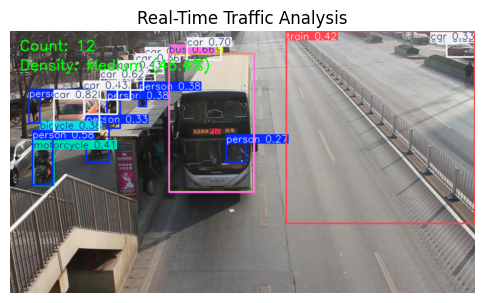

Vehicle Count: 12
Traffic Density: Medium
Prediction Accuracy: 62.93 %

Next 15 Minute Prediction:
[ 9 10 10 11 11 12 12 12 12 13 13 13 13 13 13]


In [ ]:
test_image = os.path.join(base_path, "MVI_20012", "img00874.jpg")
full_demo(test_image)